# 13. Methanogenesis

Methanogens are at the bottom of the redox tower. Once oxygen, nitrate,
manganese, iron and sulfate are gone, carbon has nobody left to give its
electrons to except carbon. Methanogenesis is what happens then, and it is
the last step in the anaerobic breakdown of organic matter.

This notebook groups the pathways by **where the electrons come from**:

* **Type I — hydrogenotrophic.** CO₂ is the acceptor and H₂ (or formate)
  is the donor:
  $$4\,H_2 + CO_2 \rightarrow CH_4 + 2\,H_2O$$
* **Type II — methyl and acetate.** The substrate already carries a methyl
  group, and the electrons either come from the substrate itself or from
  H₂:
  * *aceticlastic* — $CH_3COO^- + H^+ \rightarrow CH_4 + CO_2$
  * *methylotrophic disproportionation* —
    $4\,CH_3OH \rightarrow 3\,CH_4 + CO_2 + 2\,H_2O$, and the same with
    methylamines and methyl sulfides
  * *methyl reduction* — $CH_3OH + H_2 \rightarrow CH_4 + H_2O$

A caution on the names. In the literature, "Type I" and "Type II" are not
standard. The well-known physiological split (Thauer *et al.* 2008, *Nat.
Rev. Microbiol.*) is between methanogens **with cytochromes** (the
Methanosarcinales, which grow on acetate and methyl compounds) and those
**without** (most hydrogenotrophs, and also the obligate methyl reducers
such as *Methanosphaera*). That split cuts across this one: methyl reduction
is "Type II" by substrate but is done by organisms without cytochromes. The
labels here describe the chemistry, not the taxonomy.

What this notebook covers:

1. a Frost diagram of every methanogenic substrate, which shows that
   **every Type II pathway is a disproportionation**;
2. the half reactions for each type;
3. ΔG°′ for each pathway, per mole of CH₄, and why the convention matters;
4. syntrophy: an H₂ producer, a methanogen, and the two together;
5. what happens as H₂ falls, and how methyl reducers can hold H₂ below what
   a hydrogenotroph can live on;
6. reverse methanogenesis.

Every number is computed here, not quoted.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

import microbial_thermo as mt
from microbial_thermo import Couple
from microbial_thermo.figures import (
    frost_diagram,
    plot_affinity_ladder,
    plot_energy_explorer,
    plot_frost,
    plot_half_reactions,
    plot_syntrophy_interactive,
    plot_syntrophy_window,
    syntrophy_window,
)
from microbial_thermo.figures.basis import FARADAY_KJ
from microbial_thermo.figures.explorer import SVG_CONFIG
from microbial_thermo.library import reaction

warnings.filterwarnings("ignore", category=UserWarning)

## 1. The substrates on a Frost diagram

A Frost diagram plots each species' **volt equivalent** (its free energy of
formation from the element, per carbon, divided by the Faraday constant)
against carbon's oxidation state. The slope between two points is the
potential of that couple. A point that sits **above** the straight line
joining two others is unstable and can disproportionate into them.

Here are the substrates: CO₂ and bicarbonate, formate, acetate, the
placeholder biomass ⟨CH₂O⟩, methanol, methylamine, methanethiol, dimethyl
sulfide (DMS) and methane.

**What is in the databases.** Methylamine (as the neutral amine, CH₃NH₂)
comes from the primary database (speq23). DMS and methanethiol come from the
OBIGT import (Schulte 2010; Schulte & Rogers 2004). **Trimethylamine,
dimethylamine and TMAO are in none of our databases**, so they are left out
rather than guessed.

Two choices had to be made to draw this.

* **Graphite is left out.** It stays the zero of the y axis, because the
  element reference does not depend on which species you draw. If graphite
  were included, the hull would run through it at C(0), and the diagram
  would say DMS falls apart into graphite and methane. That is true, and it
  is irrelevant: no organism makes graphite. Leaving it out makes the hull
  the line from CH₄ to HCO₃⁻, the only end products a methanogen makes.
* **The sulfur and nitrogen are held as HS⁻ and NH₄⁺.** DMS contains sulfur
  and methylamine contains nitrogen, so their formation reactions need a
  form of S and N to start from. HS⁻ and NH₄⁺ are what methanogenesis
  releases. Because S is −II in both DMS and HS⁻, and N is −III in both
  methylamine and NH₄⁺, the electron count is carbon's alone, and the
  library checks this from each molecule's structure before it will draw
  the point. Against the default sulfate basis it refuses, correctly.

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


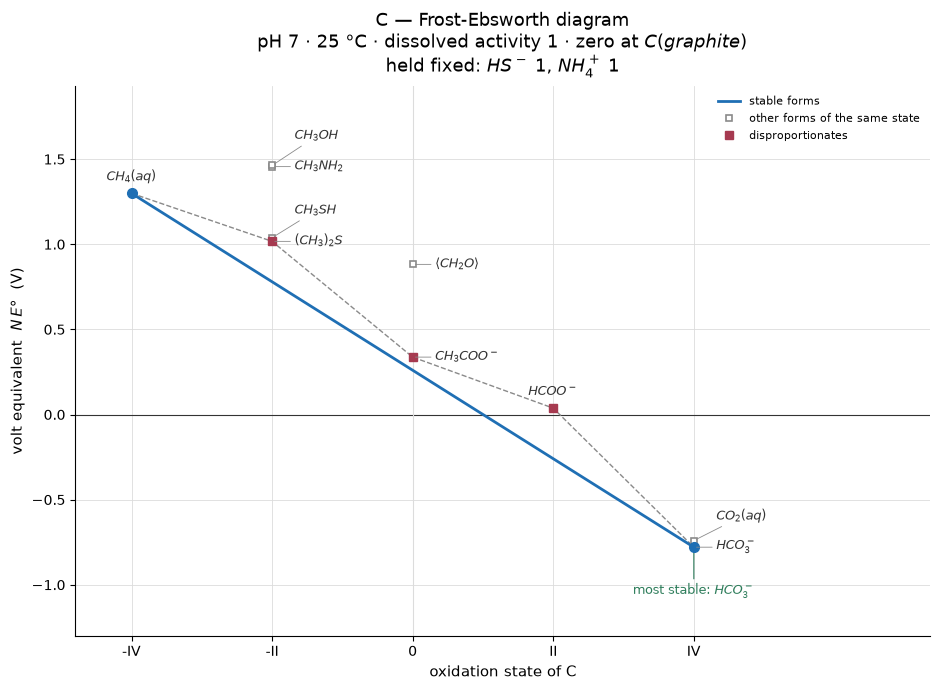

In [2]:
substrates = [
    "HCO3-",
    "CO2(aq)",
    "Formate(aq)",
    "Acetate",
    "Biomass(aq)",
    "Methanol(aq)",
    "Methanamine(aq)",
    "methanethiol",
    "dimethyl sulfide",
    "Methane(aq)",
]
held = {"S": ("HS-", 1.0), "N": ("NH4+", 1.0)}

frost = frost_diagram("C", species=substrates, pH=7.0, predominant_only=False, fixed=held)
plot_frost("C", diagram=frost, label="all", figsize=(9.5, 7.0))
plt.show()

**Methane and bicarbonate are the only two points on the hull.** Everything
else sits above the line joining them. So every substrate on this diagram
can, in principle, be split into CH₄ and HCO₃⁻ with energy to spare. That
is what methanogenesis is:

* **Type II pathways are disproportionations.** Acetate, methanol,
  methylamine and DMS each split their own carbon into a more reduced part
  (CH₄) and a more oxidised part (CO₂). No outside electron donor is needed.
* **Type I is the hull itself, run with outside help.** CO₂ is already at
  the bottom-right end of the line. Turning it into CH₄ means climbing the
  hull, which needs electrons from somewhere else: H₂.

A note on the legend. At C(−II) four different compounds share one
x position. The library treats points at the same oxidation state as
"forms of the same state" and colours only the lowest (DMS) as the
predominant one; methanol, methylamine and methanethiol are drawn as open
grey squares. Here that does **not** mean they are stable. They are
different compounds, not acid–base forms of one compound, and all three sit
above the CH₄–HCO₃⁻ line too.

On this diagram the **vertical height of a substrate above the chord**,
times the Faraday constant, is the energy released per carbon when it
disproportionates. The next cell measures it.

In [3]:
points = {point.backend: point for point in frost.points}
methane, bicarbonate = points["Methane(aq)"], points["HCO3-"]


def chord(state):
    """Volt equivalent on the straight CH4 -> HCO3- line at this oxidation state."""
    fraction = (state - methane.oxidation_state) / (
        bicarbonate.oxidation_state - methane.oxidation_state
    )
    return methane.volt_equivalent + fraction * (
        bicarbonate.volt_equivalent - methane.volt_equivalent
    )


rows = []
for name in [
    "Acetate",
    "Methanol(aq)",
    "Methanamine(aq)",
    "methanethiol",
    "dimethyl sulfide",
    "Formate(aq)",
    "Biomass(aq)",
]:
    point = points[name]
    height = point.volt_equivalent - chord(point.oxidation_state)
    rows.append(
        {
            "species": name,
            "C oxidation state": point.oxidation_state,
            "height above CH4-HCO3- line (V)": round(height, 3),
            "dG per mol C (kJ)": round(-height * FARADAY_KJ, 1),
        }
    )
heights = pd.DataFrame(rows).set_index("species")
heights

,C oxidation state,height above CH4-HCO3- line (V),dG per mol C (kJ)
species,,,
Acetate,0.0,0.077,-7.4
Methanol(aq),-2.0,0.683,-65.9
Methanamine(aq),-2.0,0.676,-65.3
methanethiol,-2.0,0.259,-25.0
dimethyl sulfide,-2.0,0.237,-22.9
Formate(aq),2.0,0.297,-28.7
Biomass(aq),0.0,0.622,-60.0


**Check it a second way.** The Frost diagram and the reaction balancer share
the database but nothing else. If the height above the chord really is the
disproportionation energy, then balancing acetate → CH₄ + HCO₃⁻ as a
reaction must give the same number. Acetate has two carbons:

In [4]:
standard = mt.Conditions(temperature_c=25.0, pH=7.0)

acetate_split = mt.Reaction.from_couples(
    donor=Couple.make("acetate", "HCO3-", key_element="C"),
    acceptor=Couple.make("methane", "HCO3-", key_element="C"),
    conditions=standard,
    normalize_to="methane",
)
print(acetate_split.format())
print(
    f"from the balanced reaction: {acetate_split.delta_G_standard_prime.magnitude:+.1f} kJ/mol acetate"
)
print(
    f"from the Frost diagram:     {2 * heights.loc['Acetate', 'dG per mol C (kJ)']:+.1f} kJ/mol acetate"
)

Acetate + H2O -> HCO3- + Methane(aq)
from the balanced reaction: -14.9 kJ/mol acetate
from the Frost diagram:     -14.8 kJ/mol acetate


They agree. Three more things the table and diagram say:

* **Acetate is barely above the line.** It gives the least energy per
  carbon of any substrate here, which is why aceticlastic methanogens
  (*Methanothrix*, formerly *Methanosaeta*) grow so slowly.
* **Methanol and methylamine are far above it.** They are the richest
  substrates per carbon. DMS and methanethiol are C(−II) too, but sit much
  lower, because the C–S bond makes them more stable to begin with.
* **Biomass is well above the line.** Building ⟨CH₂O⟩ from CO₂ is uphill,
  and a methanogen has to pay for it out of the small energy its catabolism
  releases. (⟨CH₂O⟩ is a placeholder, not a measured compound — see its
  provenance in `supplemental_gibbs.yaml`.)

## 2. The half reactions

Every redox reaction is an oxidation and a reduction added together. For
methanogenesis the acceptor is always some form of carbon going to CH₄; what
changes is the donor.

### Type I — hydrogenotrophic

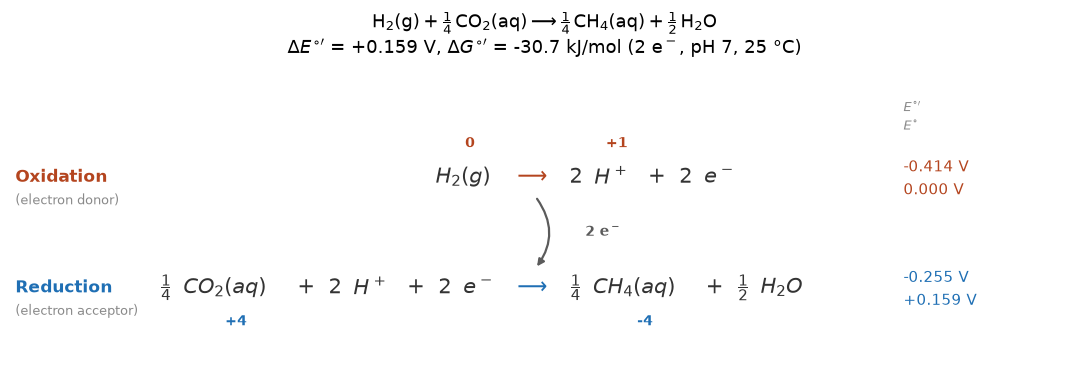

In [5]:
type_one = reaction("hydrogenotrophic_methanogenesis", standard)
plot_half_reactions(type_one)
plt.show()

H₂ gives up its electrons at −0.41 V; CO₂ takes them at −0.26 V. The gap is
only about 0.16 V, which is why methanogenesis pays so little.

Formate methanogenesis is the same thing. Formate is oxidised to CO₂ at
almost the same potential as H₂, and many hydrogenotrophs use both:

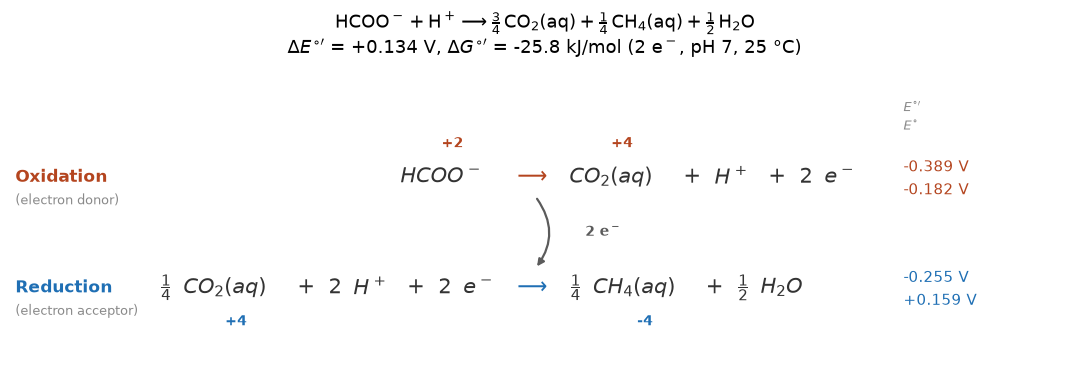

In [6]:
plot_half_reactions(reaction("formate_methanogenesis", standard))
plt.show()

### Type II — aceticlastic

Written as half reactions, acetate is both the donor (oxidised to CO₂) and,
through the CO₂, the acceptor. The two potentials are almost equal, which
is the half-reaction picture of "barely above the line" on the Frost
diagram.

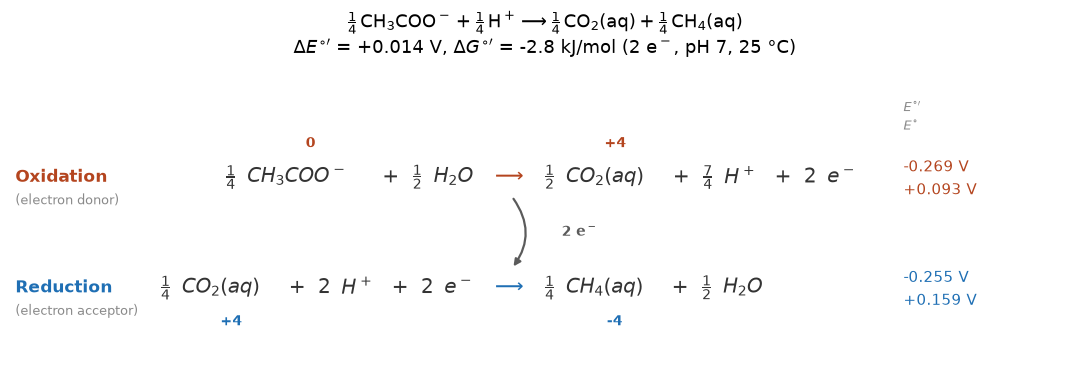

In [7]:
plot_half_reactions(reaction("acetoclastic_methanogenesis", standard))
plt.show()

### Type II — methylotrophic disproportionation

One methanol in four is oxidised to CO₂ to provide the electrons that reduce
the other three to CH₄:

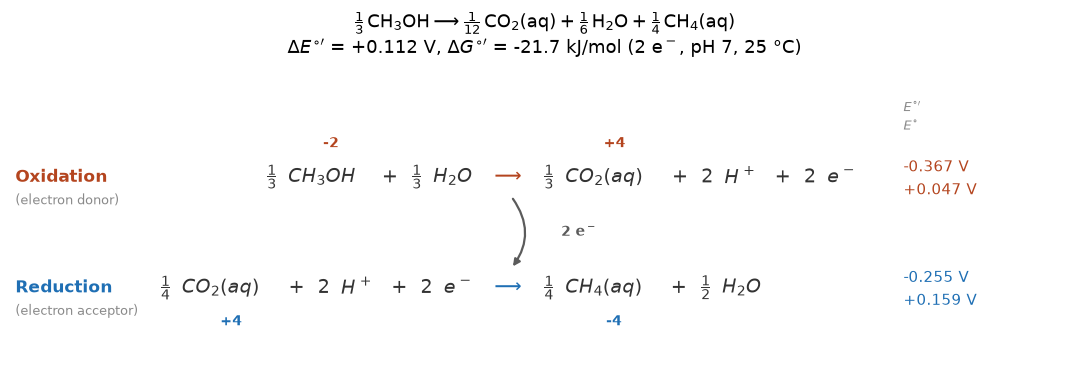

In [8]:
plot_half_reactions(reaction("methylotrophic_methanogenesis", standard))
plt.show()

The same pattern with dimethyl sulfide. Note the HS⁻ released on the donor
side — it is why DMS needed a sulfide basis on the Frost diagram:

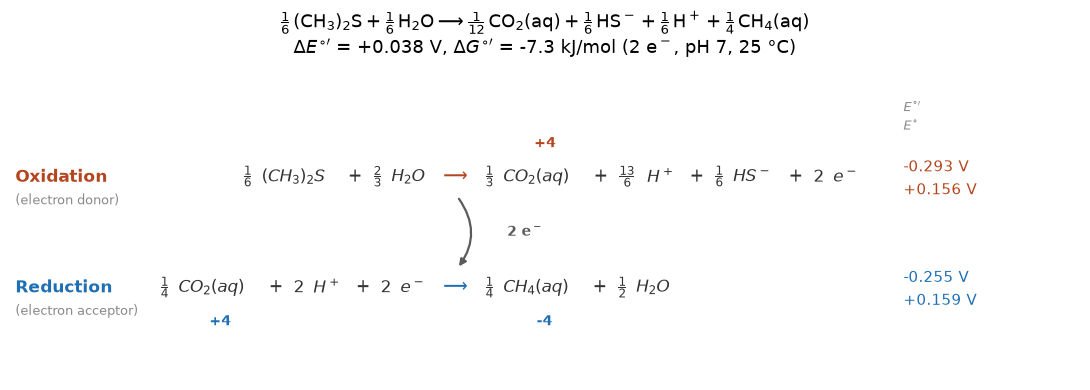

In [9]:
plot_half_reactions(reaction("dms_methanogenesis", standard))
plt.show()

### Type II — methyl reduction

The obligate methyl reducers (*Methanosphaera*, the Methanomassiliicoccales)
cannot oxidise methyl groups to CO₂ at all. They take every electron from
H₂ and spend it on reducing methyl groups straight to methane:

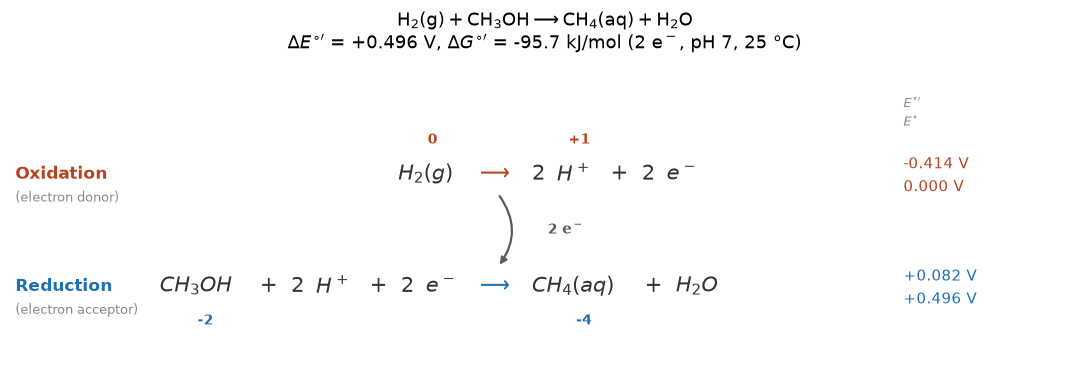

In [10]:
methyl_reduction = reaction("methyl_reducing_methanogenesis", standard)
plot_half_reactions(methyl_reduction)
plt.show()

Compare this figure with the Type I one. **The donor is identical**: H₂ at
−0.41 V. The acceptor is different: a methyl group accepts electrons at a
far more positive potential than CO₂ does. Per H₂, methyl reduction
releases about three times as much energy as CO₂ reduction. Section 5 shows
why that matters.

### A note on counting electrons in a disproportionation

The library writes methanol, methylamine and DMS disproportionation
**through CO₂**: substrate → CO₂ on the donor side and CO₂ → CH₄ on the
acceptor side. The net reaction is exact. But this way of writing it counts
24 electrons for 4 CH₃OH → 3 CH₄ + CO₂, whereas the methyl chemistry
actually moves 6 (one methyl gives 6 e⁻ to reduce three others by 2 e⁻
each). Both give the same energy per CH₄; only the per-electron number
changes:

In [11]:
direct = mt.Reaction.from_couples(
    donor=Couple.make("methanol", "CO2(aq)", key_element="C"),
    acceptor=Couple.make("methane", "methanol", key_element="C"),
    conditions=standard,
    normalize_to="methane",
)
through_co2 = reaction("methylotrophic_methanogenesis", standard, normalize_to="methane")
for label, built in (("CH3OH/CH4 couple", direct), ("through CO2", through_co2)):
    per_ch4 = built.delta_G_standard_prime.magnitude
    per_e = built.delta_G_standard_prime.magnitude / built.n_electrons
    print(
        f"{label:18s} {built.n_electrons} e- per CH4   {per_ch4:+7.1f} kJ/mol CH4   {per_e:+6.1f} kJ/mol e-"
    )

CH3OH/CH4 couple   2 e- per CH4     -86.6 kJ/mol CH4    -43.3 kJ/mol e-
through CO2        8 e- per CH4     -86.6 kJ/mol CH4    -10.8 kJ/mol e-


So **compare methanogenic pathways per mole of CH₄, not per electron**. Per
CH₄ is a fixed quantity. Per electron depends on how you choose to write the
reaction, and for a disproportionation there is no single right way.

## 3. ΔG°′ for each pathway

Standard conditions at pH 7: every solute at 1 M, H₂ at 1 bar, 25 °C. Two
columns, because there are two common conventions for methane and CO₂:

* **solutes at 1 M** — CH₄(aq) and CO₂(aq), as the cell sees them. This is
  the convention the rest of this library uses.
* **gases at 1 bar** — CH₄(g) and CO₂(g), as in Thauer, Jungermann &
  Decker (1977, *Bacteriol. Rev.*), the table most textbooks reproduce.

Everything is per mole of CH₄ made.

In [12]:
def pathway(donor, acceptor, gas):
    """One methanogenic reaction per mole of CH4, in either convention.

    ``donor`` and ``acceptor`` are (reduced, oxidized) couples written with
    the placeholders "CH4" and "CO2", which become the gas or the dissolved
    form. Carbon is named as the key element wherever the couple contains it.
    """
    ch4, co2 = ("CH4(g)", "CO2(g)") if gas else ("methane", "CO2(aq)")

    def swap(side):
        if isinstance(side, str):
            return {"CH4": ch4, "CO2": co2}.get(side, side)
        return [[swap(item[0]), item[1]] if isinstance(item, list) else swap(item) for item in side]

    def couple(pair):
        reduced, oxidized = swap(pair[0]), swap(pair[1])
        has_carbon = "H2(g)" not in (reduced, oxidized)
        return Couple.make(reduced, oxidized, key_element="C" if has_carbon else None)

    return mt.Reaction.from_couples(
        donor=couple(donor), acceptor=couple(acceptor), conditions=standard, normalize_to=ch4
    )


H2 = ("H2(g)", "H+")
TO_CH4 = ("CH4", "CO2")
pathways = {
    ("Type I", "H2 + CO2"): (H2, TO_CH4),
    ("Type I", "formate"): (("formate", "CO2"), TO_CH4),
    ("Type II: aceticlastic", "acetate"): (("acetate", "CO2"), TO_CH4),
    ("Type II: disproportionation", "methanol"): (("methanol", "CO2"), TO_CH4),
    ("Type II: disproportionation", "methylamine"): (("methylamine", ["CO2", "NH4+"]), TO_CH4),
    ("Type II: disproportionation", "methanethiol"): (("methanethiol", ["CO2", "HS-"]), TO_CH4),
    ("Type II: disproportionation", "DMS"): (("DMS", [["CO2", 2], ["HS-", 1]]), TO_CH4),
    ("Type II: methyl reduction", "methanol + H2"): (H2, ("CH4", "methanol")),
    ("Type II: methyl reduction", "methylamine + H2"): (H2, (["CH4", "NH4+"], "methylamine")),
    ("Type II: methyl reduction", "methanethiol + H2"): (H2, (["CH4", "HS-"], "methanethiol")),
    ("Type II: methyl reduction", "DMS + H2"): (H2, ([["CH4", 2], ["HS-", 1]], "DMS")),
}

rows = []
for (group, substrate), (donor, acceptor) in pathways.items():
    dissolved = pathway(donor, acceptor, gas=False)
    gaseous = pathway(donor, acceptor, gas=True)
    rows.append(
        {
            "type": group,
            "substrate": substrate,
            "ΔG°' solutes 1 M (kJ/mol CH4)": round(dissolved.delta_G_standard_prime.magnitude, 1),
            "ΔG°' gases 1 bar (kJ/mol CH4)": round(gaseous.delta_G_standard_prime.magnitude, 1),
            "reaction (solutes)": dissolved.format(),
        }
    )
delta_g_table = pd.DataFrame(rows).set_index(["type", "substrate"])
delta_g_table

ΔG°' solutes 1 M (kJ/mol CH4)  \
type                        substrate                                          
Type I                      H2 + CO2                                  -122.8   
                            formate                                   -103.4   
Type II: aceticlastic       acetate                                    -11.1   
Type II: disproportionation methanol                                   -86.6   
                            methylamine                                -85.8   
                            methanethiol                               -32.0   
                            DMS                                        -29.3   
Type II: methyl reduction   methanol + H2                              -95.7   
                            methylamine + H2                           -95.0   
                            methanethiol + H2                          -54.7   
                            DMS + H2                                   -52.7   

                                               ΔG°' gases 1 bar (kJ/mol CH4)  \
type                        substrate                                          
Type I                      H2 + CO2                                  -130.7   
                            formate                                   -144.8   
Type II: aceticlastic       acetate                                    -35.8   
Type II: disproportionation methanol                                  -105.7   
                            methylamine                               -104.8   
                            methanethiol                               -51.1   
                            DMS                                        -48.3   
Type II: methyl reduction   methanol + H2                             -112.0   
                            methylamine + H2                          -111.3   
                            methanethiol + H2                          -71.0   
                            DMS + H2                                   -68.9   

                                                                              reaction (solutes)  
type                        substrate                                                             
Type I                      H2 + CO2                    4 H2(g) + CO2(aq) -> Methane(aq) + 2 H2O  
                            formate            4 Formate(aq) + 4 H+ -> 3 CO2(aq) + Methane(aq...  
Type II: aceticlastic       acetate                        Acetate + H+ -> CO2(aq) + Methane(aq)  
Type II: disproportionation methanol           4/3 Methanol(aq) -> 1/3 CO2(aq) + 2/3 H2O + Me...  
                            methylamine        4/3 Methanamine(aq) + 2/3 H2O + 4/3 H+ -> 1/3 ...  
                            methanethiol       4/3 methanethiol + 2/3 H2O -> 1/3 CO2(aq) + 4/...  
                            DMS                2/3 dimethyl sulfide + 2/3 H2O -> 1/3 CO2(aq) ...  
Type II: methyl reduction   methanol + H2              H2(g) + Methanol(aq) -> Methane(aq) + H2O  
                            methylamine + H2   H+ + H2(g) + Methanamine(aq) -> Methane(aq) + ...  
                            methanethiol + H2     H2(g) + methanethiol -> H+ + Methane(aq) + HS-  
                            DMS + H2           H2(g) + 1/2 dimethyl sulfide -> 1/2 H+ + Metha...

What to take from the table:

* **The convention moves the numbers by 8 to 41 kJ/mol.** CH₄(g) is
  16 kJ/mol more stable than CH₄(aq) at unit activity, and CO₂(g) is about
  8 kJ/mol more stable than CO₂(aq). Aceticlastic methanogenesis is
  −36 kJ/mol in the gas convention and only −11 in the dissolved one. A
  ΔG°′ means nothing unless you say which species it is written for.
* **The gas column reproduces the textbook table.** Thauer *et al.* (1977)
  give −131 for H₂/CO₂, −36 for acetate, −112.5 for methanol + H₂ and −49
  for DMS; compare the second column.
* **Methyl reduction beats disproportionation for every methyl substrate**,
  because H₂ is a better donor than a methyl group being oxidised to CO₂.

**Methylamine needs a correction.** The database has only neutral CH₃NH₂.
At pH 7 methylamine is almost entirely methylammonium, CH₃NH₃⁺
(p*K*a ≈ 10.6). Starting from 1 M methylammonium instead of 1 M neutral
amine costs the deprotonation energy, $2.303\,RT\,(\mathrm{p}K_a - 7)$, for
each methylamine consumed:

In [13]:
R_KJ = 8.314462618e-3  # kJ/(mol K)
T = 298.15
pka_methylammonium = 10.6
deprotonation = np.log(10) * R_KJ * T * (pka_methylammonium - 7.0)
per_ch4 = delta_g_table.loc[
    ("Type II: disproportionation", "methylamine"), "ΔG°' gases 1 bar (kJ/mol CH4)"
]
corrected = per_ch4 + (4 / 3) * deprotonation
print(f"deprotonation at pH 7: {deprotonation:.1f} kJ/mol methylamine")
print(
    f"methylamine disproportionation, gas convention: {per_ch4:+.1f} -> {corrected:+.1f} kJ/mol CH4"
)

deprotonation at pH 7: 20.5 kJ/mol methylamine
methylamine disproportionation, gas convention: -104.8 -> -77.4 kJ/mol CH4


With methylammonium as the substrate the value is about −77 kJ/mol CH₄,
close to Thauer's −75. The uncorrected number in the table is too
favourable by about 27 kJ/mol CH₄. That is the size of error you get from
using the wrong protonation state, and it is close to the whole energy
yield of aceticlastic methanogenesis (−36 kJ/mol CH₄ in the same
convention).

## 4. Syntrophy: an H₂ producer and a hydrogenotroph

In 1967 Bryant and colleagues showed that *Methanobacillus omelianskii*, a
culture thought to turn ethanol into methane on its own, was actually **two
organisms** (Bryant *et al.* 1967, *Arch. Mikrobiol.*). The "S organism"
oxidised ethanol to acetate and H₂. A hydrogenotrophic methanogen ate the
H₂. Neither could grow on ethanol alone.

Thermodynamics says why. Ethanol oxidation releases H₂ and is held back by
it. The methanogen consumes H₂ and needs enough of it. The conditions below
are a methanogenic digester or sediment.

In [14]:
digester = mt.Conditions(
    temperature_c=25.0,
    pH=7.0,
    activity_model="ideal",
    partial_pressures={"H2(g)": 1e-5},
    concentrations={
        "Ethanol(aq)": 1e-3,
        "Acetate": 1e-3,
        "HCO3-": 2e-2,
        "CO2(aq)": 1e-2,
        "Methane(aq)": 1e-3,
        "Methanol(aq)": 1e-4,
        "SO4-2": 1e-3,
        "HS-": 1e-4,
    },
)

producer = reaction("syntrophic_ethanol_oxidation", digester)
consumer = reaction("hydrogenotrophic_methanogenesis", digester)
print("producer:", producer.format())
print("consumer:", consumer.format())

producer: 1/2 Ethanol(aq) + 1/2 H2O -> 1/2 Acetate + 1/2 H+ + H2(g)
consumer: H2(g) + 1/4 CO2(aq) -> 1/4 Methane(aq) + 1/2 H2O


### The H₂ producer alone

The interactive explorer shows one reaction's free energy against whatever
you choose from the dropdown. Choose **H2(g)**. As H₂ builds up, ethanol
oxidation stops paying: on its own the S organism poisons itself with its
own product.

In [15]:
explorer_producer = plot_energy_explorer(
    producer,
    title="Ethanol oxidation alone (the S organism)",
    save_html="syntrophy_ethanol_oxidizer",
)
explorer_producer.show(config=SVG_CONFIG)

### The methanogen alone

Now the consumer. Choose **H2(g)** again. The methanogen needs H₂ **high**.
Below a few times 10⁻⁶ bar its reaction is no longer exergonic at all.

In [16]:
explorer_consumer = plot_energy_explorer(
    consumer,
    title="Hydrogenotrophic methanogenesis alone",
    save_html="syntrophy_methanogen",
)
explorer_consumer.show(config=SVG_CONFIG)

### Both together

Put both reactions on one H₂ axis and the lines cross. The shaded band is
the range of H₂ partial pressures where **both** are exergonic at the same
time. Only there can the partnership run. The methanogen keeps H₂ low
enough for the S organism, and the S organism keeps H₂ high enough for the
methanogen.

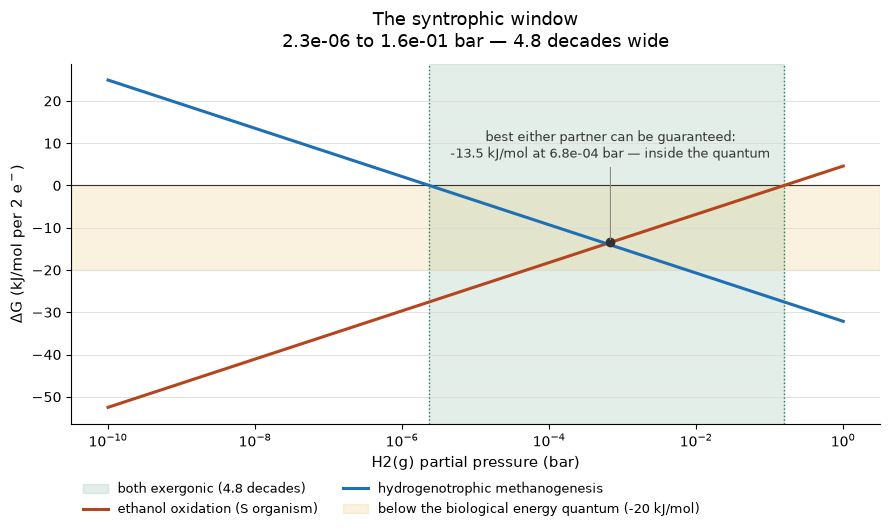

In [17]:
labels = {
    "producer_label": "ethanol oxidation (S organism)",
    "consumer_label": "hydrogenotrophic methanogenesis",
}
figure, window = plot_syntrophy_window(producer, consumer, low=1e-10, high=1.0, **labels)
plt.show()

In [18]:
together, _ = plot_syntrophy_interactive(
    producer,
    consumer,
    window=window,
    save_html="syntrophy_together",
    title="Ethanol oxidation + hydrogenotrophic methanogenesis",
    **labels,
)
together.show(config=SVG_CONFIG)

In [19]:
pressure, shared = window.best_shared
print(f"window: {window.low:.1e} to {window.high:.1e} bar H2 ({window.decades:.1f} decades)")
print(f"best shared: {shared:.1f} kJ/mol per 2 e- each, at {pressure:.1e} bar")

window: 2.3e-06 to 1.6e-01 bar H2 (4.8 decades)
best shared: -13.5 kJ/mol per 2 e- each, at 6.8e-04 bar


The three pages are written next to this notebook as
`syntrophy_ethanol_oxidizer.html`, `syntrophy_methanogen.html` and
`syntrophy_together.html`. Each is self-contained and works with no Python
behind it.

Ethanol is a generous substrate, so this window is wide. The other classic
syntrophic substrates are less generous. Here are all three at the same
digester conditions (1 mM substrate), against the same methanogen:

In [20]:
rows = []
for name in (
    "syntrophic_ethanol_oxidation",
    "syntrophic_butyrate_oxidation",
    "syntrophic_propionate_oxidation",
):
    conditions = digester.replace(
        concentrations={**digester.concentrations, "Propanoate(aq)": 1e-3, "Butanoate(aq)": 1e-3}
    )
    each = syntrophy_window(
        reaction(name, conditions), reaction("hydrogenotrophic_methanogenesis", conditions)
    )
    rows.append(
        {
            "producer": name,
            "window low (bar)": f"{each.low:.1e}",
            "window high (bar)": f"{each.high:.1e}",
            "decades": round(each.decades, 1),
            "best shared (kJ/mol per 2 e-)": round(each.best_shared[1], 1),
        }
    )
pd.DataFrame(rows).set_index("producer")

,window low (bar),window high (bar),decades,best shared (kJ/mol per 2 e-)
producer,,,,
syntrophic_ethanol_oxidation,2.3e-06,1.6e-01,4.8,-13.5
syntrophic_butyrate_oxidation,2.3e-06,1.3e-03,2.8,-7.4
syntrophic_propionate_oxidation,2.3e-06,9.7e-05,1.6,-4.5


The low edge is the same for all three, because it is set by the methanogen.
The high edge is set by the producer, and the less a substrate pays, the
lower the H₂ it can tolerate. Propionate leaves the partners less than two
decades of H₂ and under 5 kJ/mol each at best.

## 5. As H₂ falls, who still gets paid?

The affinity ladder ranks every metabolism by free energy per electron at
one set of conditions. Below it is drawn for the methanogens, with the two
other big H₂ consumers in anoxic environments for comparison (sulfate
reducers and homoacetogens), at three H₂ partial pressures.

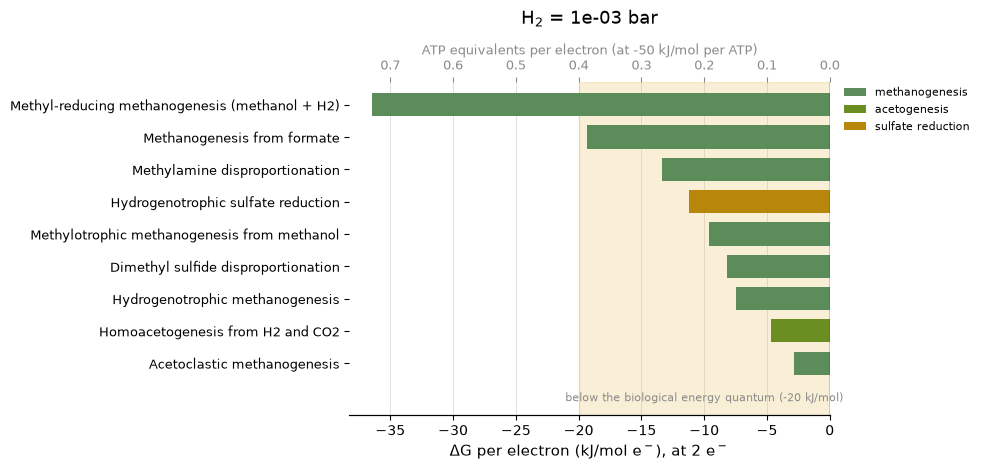

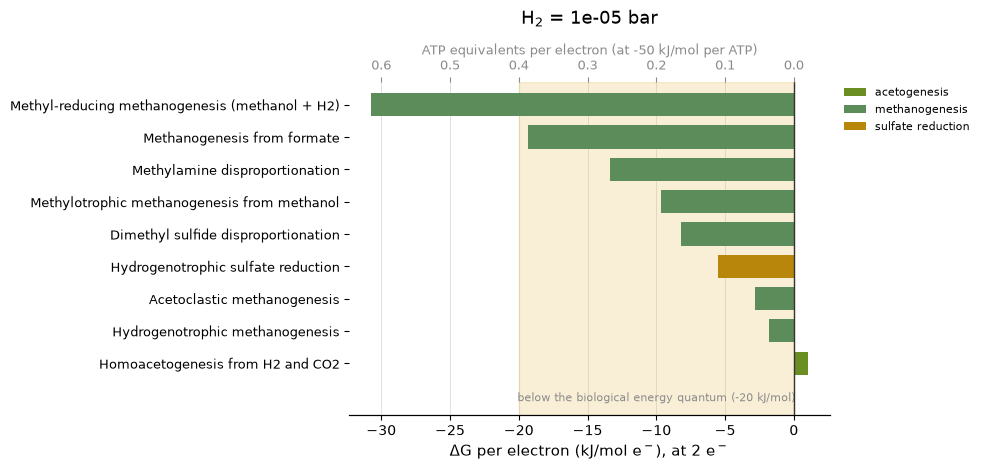

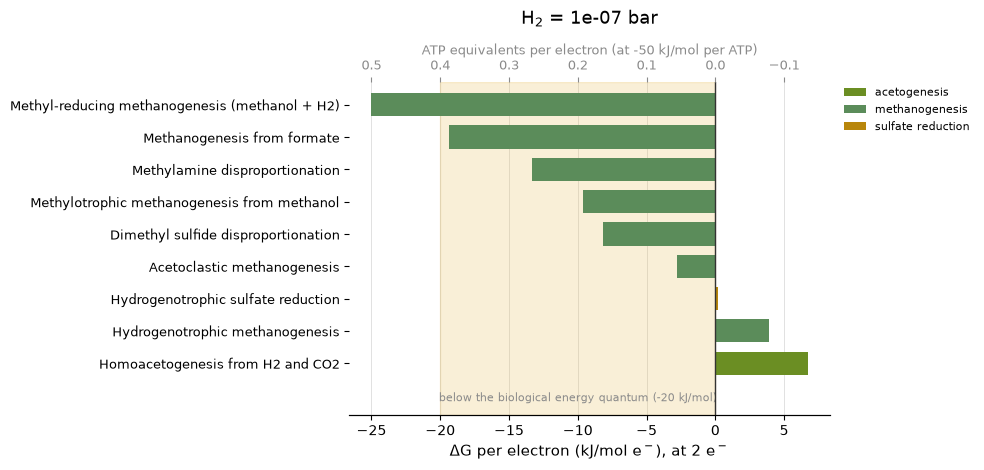

In [21]:
def methanogen_table(h2_bar):
    """Energy table for the methanogens and their H2 competitors at one pH2."""
    conditions = digester.replace(partial_pressures={"H2(g)": h2_bar})
    table = mt.energy_table(conditions)
    keep = (table["group"] == "methanogenesis") | table["name"].isin(
        ["hydrogenotrophic_sulfate_reduction", "acetogenesis"]
    )
    return conditions, table[keep]


for h2_bar in (1e-3, 1e-5, 1e-7):
    conditions, table = methanogen_table(h2_bar)
    plot_affinity_ladder(
        conditions,
        table=table,
        figsize=(10, 4.8),
        title=f"H$_2$ = {h2_bar:.0e} bar",
    )
    plt.show()

Watch which bars move.

* **Formate, acetate and the methyl disproportionations do not move at
  all.** No H₂ in the reaction, so H₂ cannot affect them. (The methyl
  disproportionation bars are short partly because of the per-electron
  counting described in section 2.)
* **Everything that eats H₂ shrinks as H₂ falls**, but not equally.
  Homoacetogenesis goes first, then hydrogenotrophic methanogenesis, then
  sulfate reduction. At 10⁻⁷ bar the hydrogenotroph is endergonic.
* **Methyl reduction hardly notices.** It starts so far ahead that it is
  still the best-paid H₂ consumer on the ladder at 10⁻⁷ bar.

The bars for the H₂ consumers are per 2 e⁻, which is per H₂. Here that is
an exact comparison, not a convention.

### The H₂ floor

Each H₂ consumer has an H₂ partial pressure below which its reaction is no
longer exergonic: its **thermodynamic floor**. Below the floor it cannot
use H₂ at all, whatever its enzymes. A real cell needs some energy left
over to make ATP, so its measured **threshold** sits above the floor.

For any H₂ consumer written per H₂, ΔG depends on H₂ through one term,
$-RT\ln p_{H_2}$, so ΔG is a straight line against $\ln p_{H_2}$. We take
two points from the library and then check the line against a third.

In [22]:
RT = R_KJ * (digester.temperature_c + 273.15)  # kJ/mol


def delta_g(name, h2_bar):
    """Free energy per 2 e- (per H2) for a named metabolism at this pH2."""
    conditions = digester.replace(partial_pressures={"H2(g)": h2_bar})
    return reaction(name, conditions).delta_G.magnitude


def h2_line(name):
    """(intercept at 1 bar, slope in ln pH2) for an H2 consumer, from two points."""
    at_one, at_low = delta_g(name, 1.0), delta_g(name, 1e-6)
    slope = (at_low - at_one) / np.log(1e-6)
    check = at_one + slope * np.log(1e-9)
    assert abs(check - delta_g(name, 1e-9)) < 1e-6, name
    return at_one, slope


consumers = {
    "hydrogenotrophic_methanogenesis": "hydrogenotrophic methanogenesis (Type I)",
    "methyl_reducing_methanogenesis": "methyl reduction, methanol + H2 (Type II)",
    "hydrogenotrophic_sulfate_reduction": "hydrogenotrophic sulfate reduction",
    "acetogenesis": "homoacetogenesis",
}
lines = {name: h2_line(name) for name in consumers}
for name, (_intercept, slope) in lines.items():
    print(f"{name:36s} slope {slope / RT:+.3f} RT per ln pH2")

hydrogenotrophic_methanogenesis      slope -1.000 RT per ln pH2
methyl_reducing_methanogenesis       slope -1.000 RT per ln pH2
hydrogenotrophic_sulfate_reduction   slope -1.000 RT per ln pH2
acetogenesis                         slope -1.000 RT per ln pH2


Every slope is −1 *RT*, which is the check that each one is written per H₂.
Now the floors, where ΔG = 0:

In [23]:
floors = {name: np.exp(-intercept / slope) for name, (intercept, slope) in lines.items()}
floor_table = pd.DataFrame(
    {
        "H2 floor (bar)": [floors[name] for name in consumers],
        "H2 floor (Pa)": [floors[name] * 1e5 for name in consumers],
    },
    index=[consumers[name] for name in consumers],
).sort_values("H2 floor (bar)")
floor_table.style.format("{:.1e}")

,H2 floor (bar),H2 floor (Pa)
"methyl reduction, methanol + H2 (Type II)",1.7e-16,1.7e-11
hydrogenotrophic sulfate reduction,1.2e-07,1.2e-02
hydrogenotrophic methanogenesis (Type I),2.3e-06,2.3e-01
homoacetogenesis,2.3e-05,2.3e+00


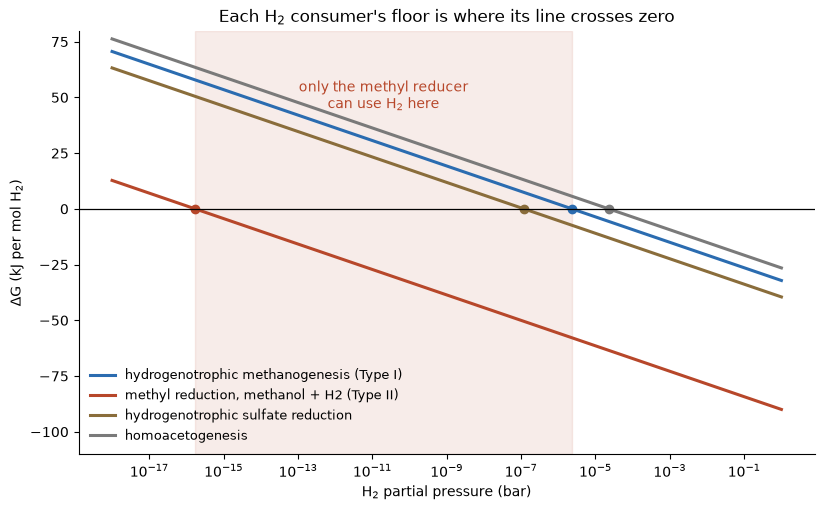

In [24]:
pressures = np.logspace(-18, 0, 400)
colours = {
    "hydrogenotrophic_methanogenesis": "#2B6CB0",
    "methyl_reducing_methanogenesis": "#B7472A",
    "hydrogenotrophic_sulfate_reduction": "#8A6D3B",
    "acetogenesis": "#7A7A7A",
}
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for name, (intercept, slope) in lines.items():
    ax.semilogx(
        pressures,
        intercept + slope * np.log(pressures),
        color=colours[name],
        linewidth=2.2,
        label=consumers[name],
    )
    ax.plot(floors[name], 0.0, "o", color=colours[name], markersize=6)
ax.axhline(0.0, color="black", linewidth=0.9)
ax.axvspan(
    floors["methyl_reducing_methanogenesis"],
    floors["hydrogenotrophic_methanogenesis"],
    color="#B7472A",
    alpha=0.10,
)
ax.annotate(
    "only the methyl reducer\ncan use H$_2$ here",
    xy=(
        np.sqrt(
            floors["methyl_reducing_methanogenesis"] * floors["hydrogenotrophic_methanogenesis"]
        ),
        45,
    ),
    ha="center",
    fontsize=10,
    color="#B7472A",
)
ax.set_xlabel("H$_2$ partial pressure (bar)")
ax.set_ylabel("ΔG (kJ per mol H$_2$)")
ax.set_ylim(-110, 80)
ax.set_title("Each H$_2$ consumer's floor is where its line crosses zero")
ax.legend(frameon=False, fontsize=9, loc="lower left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()

The methyl reducer's floor is about **ten orders of magnitude** below the
hydrogenotroph's. The reason is in the half-reaction figures: both use H₂ as
the donor, but a methyl group is a far better electron acceptor than CO₂,
so each H₂ is worth much more to the methyl reducer:


In [25]:
advantage = lines["hydrogenotrophic_methanogenesis"][0] - lines["methyl_reducing_methanogenesis"][0]
decades = np.log10(
    floors["hydrogenotrophic_methanogenesis"] / floors["methyl_reducing_methanogenesis"]
)
print(f"extra energy per H2 for the methyl reducer: {advantage:.1f} kJ/mol")
print(
    f"RT ln 10 at 25 °C: {RT * np.log(10):.2f} kJ/mol, so that is {advantage / (RT * np.log(10)):.1f} decades"
)
print(f"ratio of the two floors: {decades:.1f} decades")

extra energy per H2 for the methyl reducer: 57.8 kJ/mol
RT ln 10 at 25 °C: 5.71 kJ/mol, so that is 10.1 decades
ratio of the two floors: 10.1 decades


Every 5.7 kJ/mol per H₂ moves the floor by one factor of ten.

Measured H₂ thresholds lie above these floors, because a cell needs to
conserve some of the energy rather than run at equilibrium. The
low thresholds of obligate methyl reducers have been measured directly
(Feldewert *et al.* 2020, *FEMS Microbiol. Lett.*). The ordering is what
the thermodynamics predicts.

### Holding H₂ down: a toy competition

A floor says how low an organism *could* pull H₂. To see what happens when
both are present, here is a deliberately simple model. H₂ arrives at a
steady trickle from fermenters, plus one initial pulse. Each consumer takes
it up at a rate proportional to the H₂ present, multiplied by a
**thermodynamic factor** that falls to zero as its reaction approaches
equilibrium (after Jin & Bethke 2003, *Appl. Environ. Microbiol.*):

$$r_i = k\,p_{H_2}\,F_i, \qquad F_i = \max\!\left(0,\; 1 - e^{\Delta G_i / RT}\right)$$

Both consumers get the **same rate constant**, so any difference between
them is thermodynamic. This is a toy: no growth, no Michaelis–Menten
saturation, no minimum energy for ATP. Its only purpose is to show the
effect of the two floors.

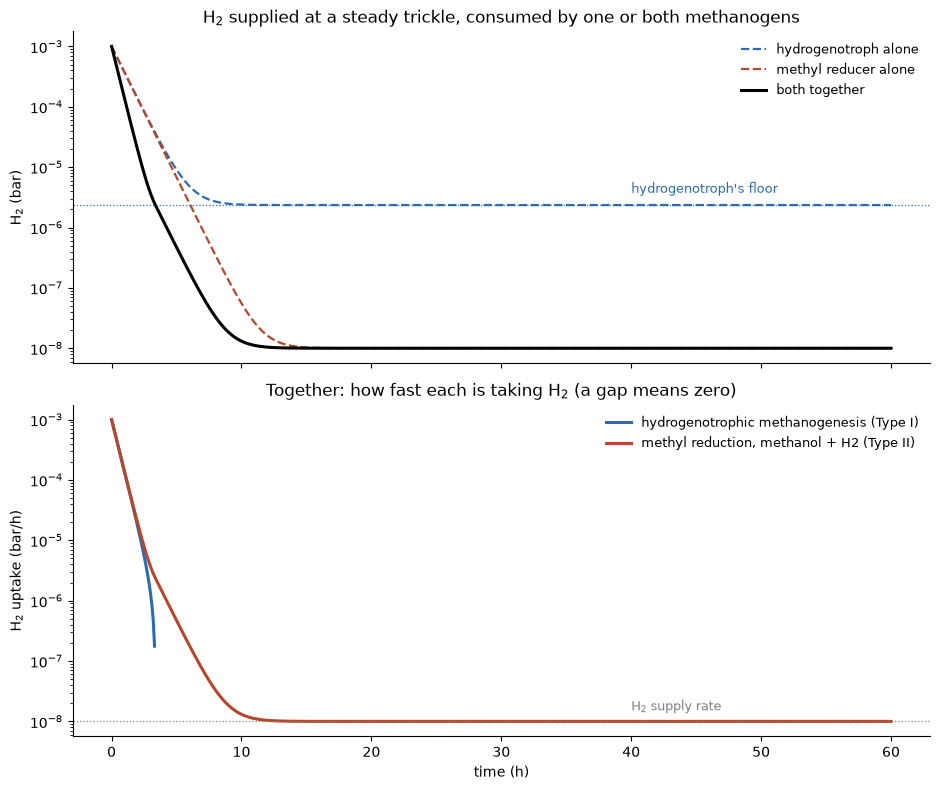

In [26]:
def thermodynamic_factor(name, h2_bar):
    intercept, slope = lines[name]
    dg = intercept + slope * np.log(h2_bar)
    return max(0.0, 1.0 - np.exp(min(dg / RT, 50.0)))


def simulate(names, supply=1e-8, pulse=1e-3, k=1.0, hours=60.0):
    """H2 partial pressure over time with the named consumers present.

    supply is in bar per hour, k in per hour. Integrated in ln(pH2) because
    the pressure spans many orders of magnitude.
    """

    def rate(_, y):
        h2 = np.exp(y[0])
        uptake = [k * h2 * thermodynamic_factor(name, h2) for name in names]
        return [(supply - sum(uptake)) / h2, *uptake]

    start = [np.log(pulse)] + [0.0] * len(names)
    times = np.linspace(0.0, hours, 600)
    solution = solve_ivp(
        rate, (0.0, hours), start, t_eval=times, method="LSODA", rtol=1e-8, atol=1e-12
    )
    return solution.t, np.exp(solution.y[0]), solution.y[1:]


scenarios = {
    "hydrogenotroph alone": ["hydrogenotrophic_methanogenesis"],
    "methyl reducer alone": ["methyl_reducing_methanogenesis"],
    "both together": ["hydrogenotrophic_methanogenesis", "methyl_reducing_methanogenesis"],
}
runs = {label: simulate(names) for label, names in scenarios.items()}

fig, (top, bottom) = plt.subplots(2, 1, figsize=(9.5, 8.0), sharex=True)
styles = {
    "hydrogenotroph alone": "#2B6CB0",
    "methyl reducer alone": "#B7472A",
    "both together": "black",
}
for label, (times, h2, _) in runs.items():
    top.semilogy(
        times,
        h2,
        color=styles[label],
        linewidth=2.2 if label == "both together" else 1.6,
        linestyle="-" if label == "both together" else "--",
        label=label,
    )
top.axhline(
    floors["hydrogenotrophic_methanogenesis"], color="#2B6CB0", linewidth=0.9, linestyle=":"
)
top.annotate(
    "hydrogenotroph's floor",
    xy=(40, floors["hydrogenotrophic_methanogenesis"] * 1.6),
    color="#2B6CB0",
    fontsize=9,
)
top.set_ylabel("H$_2$ (bar)")
top.legend(frameon=False, fontsize=9)
top.set_title("H$_2$ supplied at a steady trickle, consumed by one or both methanogens")

times, h2, _ = runs["both together"]
for name in scenarios["both together"]:
    uptake = np.array([thermodynamic_factor(name, p) for p in h2]) * h2  # k = 1 per hour
    bottom.semilogy(
        times,
        np.where(uptake > 0, uptake, np.nan),
        color=colours[name],
        linewidth=2.2,
        label=consumers[name],
    )
bottom.axhline(1e-8, color="grey", linewidth=0.9, linestyle=":")
bottom.annotate("H$_2$ supply rate", xy=(40, 1.5e-8), color="grey", fontsize=9)
bottom.set_xlabel("time (h)")
bottom.set_ylabel("H$_2$ uptake (bar/h)")
bottom.set_title("Together: how fast each is taking H$_2$ (a gap means zero)")
bottom.legend(frameon=False, fontsize=9)
for axis in (top, bottom):
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

In [27]:
print(f"hydrogenotroph's floor: {floors['hydrogenotrophic_methanogenesis']:.1e} bar")
for label, (_times, h2, _taken) in runs.items():
    print(f"{label:22s} H2 at the end: {h2[-1]:.1e} bar")
times, h2, taken = runs["both together"]
first_below = np.argmax(h2 < floors["hydrogenotrophic_methanogenesis"])
taken_after = taken[:, -1] - taken[:, first_below]
print(f"\ntogether, H2 falls below the hydrogenotroph's floor after {times[first_below]:.1f} h")
print(
    f"H2 taken after that: hydrogenotroph {taken_after[0]:.1e} bar, methyl reducer {taken_after[1]:.1e} bar"
)

hydrogenotroph's floor: 2.3e-06 bar
hydrogenotroph alone   H2 at the end: 2.4e-06 bar
methyl reducer alone   H2 at the end: 1.0e-08 bar
both together          H2 at the end: 1.0e-08 bar

together, H2 falls below the hydrogenotroph's floor after 3.4 h
H2 taken after that: hydrogenotroph 0.0e+00 bar, methyl reducer 2.8e-06 bar


Read the top panel first.

* **The hydrogenotroph alone** pulls H₂ down until it reaches its floor, and
  then stops. The trickle of new H₂ is used only as fast as it arrives, and
  H₂ stays just above the floor.
* **The methyl reducer alone** pulls H₂ to a level set by the supply rate
  (supply ÷ *k*), far below the hydrogenotroph's floor, because it is
  nowhere near its own.
* **Together**, the H₂ follows the methyl reducer's curve. Once it falls
  below the hydrogenotroph's floor the hydrogenotroph is **excluded**: its
  thermodynamic factor is zero, so it takes nothing, even though it has the
  same enzymes and the same rate constant. In the bottom panel its uptake
  line simply ends, while the methyl reducer settles at exactly the supply
  rate: from then on it takes every molecule that arrives.

Below the floor, the hydrogenotroph's reaction would actually run
**backwards** (CH₄ → CO₂ + H₂ is exergonic there). That is the subject of
the last section.

The model assumes methanol is never limiting. In nature, methyl reducers
are limited by methyl compounds: they live in places such as the animal
gut, where pectin breakdown releases methanol.

### Exercise

1. Raise `supply` to 1e-5 bar/h. Is the hydrogenotroph still excluded? Why?
   (Hint: compare supply ÷ *k* with its floor.)
2. Give the hydrogenotroph a rate constant ten times larger. Does it win
   while H₂ is high? Does it still lose in the end?

## 6. Reverse methanogenesis

Every reaction above can run backwards if the conditions change enough.
Anaerobic methane oxidation (AOM) by ANME archaea uses the methanogenic
pathway in reverse: methyl-coenzyme M reductase, the enzyme that makes
methane, is the one that activates it. The thermodynamic problem is the
same as for methanogenesis, turned around: the electrons taken from CH₄
have to go somewhere.

### Where can the electrons go?

In [28]:
seep = mt.Conditions(
    temperature_c=10.0,
    pH=7.5,
    activity_model="ideal",
    partial_pressures={"H2(g)": 1e-9},
    concentrations={
        "Methane(aq)": 1e-2,
        "SO4-2": 2.8e-2,
        "HS-": 1e-3,
        "CO2(aq)": 1e-3,
        "HCO3-": 2.5e-2,
        "NO3-": 1e-5,
        "NO2-": 1e-6,
        "N2(aq)": 5e-4,
        "Fe+2": 1e-5,
        "Mn+2": 1e-5,
        "Acetate": 1e-5,
    },
)
oxidations = mt.energy_table(seep, group="methane oxidation")
oxidations[["label", "dG (kJ/mol)", "dG per e- (kJ/mol)", "reaction"]]

,label,dG (kJ/mol),dG per e- (kJ/mol),reaction
0,Nitrite-dependent anaerobic methane oxidation ...,-216.366233,-108.183116,1/4 Methane(aq) + 2/3 H+ + 2/3 NO2- -> 1/4 CO2...
1,Anaerobic methane oxidation with Mn(IV),-153.699273,-76.849636,1/4 Methane(aq) + 2 H+ + Pyrolusite -> 1/4 CO2...
2,Anaerobic methane oxidation with nitrate,-134.279102,-67.139551,1/4 Methane(aq) + NO3- -> 1/4 CO2(aq) + 1/2 H2...
3,Anaerobic methane oxidation with ferrihydrite,-75.806931,-37.903466,1/4 Methane(aq) + 4 H+ + 2 Fe(OH)3 -> 1/4 CO2(...
4,Anaerobic oxidation of methane with sulfate,-9.723699,-4.861850,1/4 Methane(aq) + 1/4 H+ + 1/4 SO4-- -> 1/4 CO...


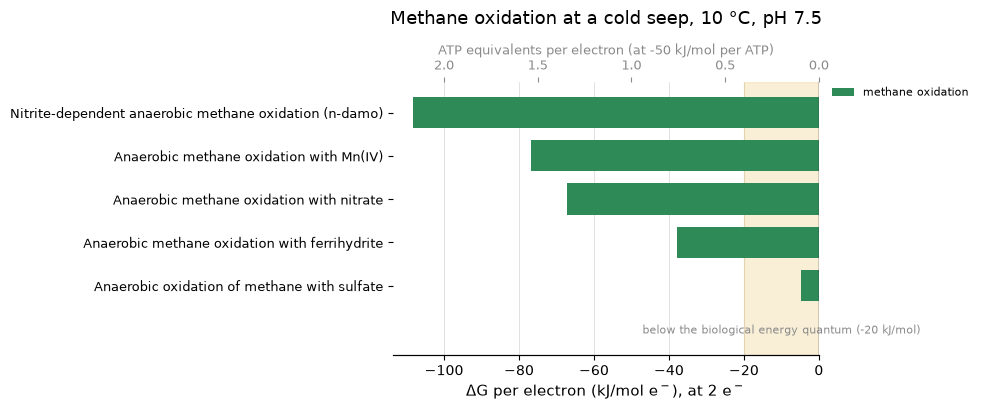

In [29]:
plot_affinity_ladder(
    seep,
    table=oxidations,
    figsize=(10, 4.2),
    title="Methane oxidation at a cold seep, 10 °C, pH 7.5",
)
plt.show()

These are the ways reverse methanogenesis is known or proposed to be
completed.

* **Sulfate, through a bacterial partner.** The classic ANME-1/2/3
  consortia with *Desulfosarcina*/*Desulfococcus* relatives. It is the
  worst-paid option on the ladder, and it still removes most of the methane
  produced in marine sediments, because sulfate is abundant there.
* **Nitrate, alone.** *Ca.* Methanoperedens nitroreducens (ANME-2d)
  reduces nitrate to nitrite itself (Haroon *et al.* 2013, *Nature*).
* **Fe(III) and Mn(IV) oxides, alone.** Methanoperedens relatives do this
  too (Ettwig *et al.* 2016, *PNAS*; Cai *et al.* 2018; Leu *et al.* 2020).
  Note how much the mineral matters: Mn(IV) pays about twice as much as
  ferrihydrite per electron.
* **Nitrite, but not by an archaeon.** *Ca.* Methylomirabilis oxyfera
  (n-damo) is a bacterium that makes its own O₂ and uses an aerobic
  methane monooxygenase. It is in the table because it oxidises methane
  without O₂ from outside, not because it reverses methanogenesis.

### Could the partner be fed with H₂?

The first explanation proposed for sulfate-dependent AOM was the
hydrogenotrophic syntrophy of section 4 run in reverse: the archaeon makes
H₂ from CH₄, and a sulfate reducer eats it (Hoehler *et al.* 1994, *Global
Biogeochem. Cycles*). Here is that window:

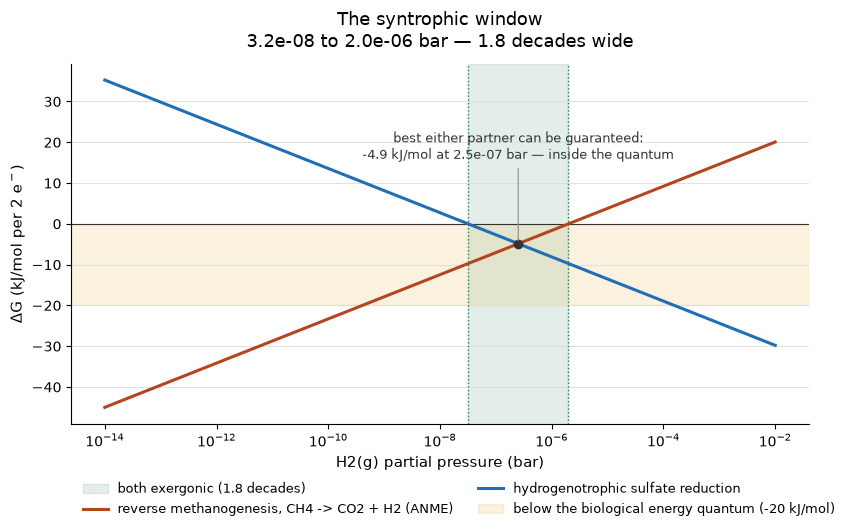

window: 3.2e-08 to 2.0e-06 bar (1.79 decades)
best shared: -4.9 kJ/mol per 2 e- each, at 2.5e-07 bar


In [30]:
reverse = mt.Reaction.from_couples(
    donor=Couple.make("methane", "CO2(aq)", key_element="C"),
    acceptor=("H2(g)", "H+"),
    conditions=seep,
)
sulfate_reducer = reaction("hydrogenotrophic_sulfate_reduction", seep)

figure, reverse_window = plot_syntrophy_window(
    reverse,
    sulfate_reducer,
    producer_label="reverse methanogenesis, CH4 -> CO2 + H2 (ANME)",
    consumer_label="hydrogenotrophic sulfate reduction",
    low=1e-14,
    high=1e-2,
    points=121,
)
plt.show()
print(
    f"window: {reverse_window.low:.1e} to {reverse_window.high:.1e} bar ({reverse_window.decades:.2f} decades)"
)
pressure, shared = reverse_window.best_shared
print(f"best shared: {shared:+.1f} kJ/mol per 2 e- each, at {pressure:.1e} bar")

Compare this with the ethanol window in section 4. There is a window, but
at its best neither partner gets more than a few kJ/mol per H₂ — far inside
the band this library marks as too little to conserve energy. And H₂ must
stay inside a narrow range of extremely low pressures, while being passed
between two cells. At such low concentrations, diffusion can move only a
tiny flux of H₂ between cells, so the archaeon would have to sit
impossibly close to its partner for H₂ transfer to keep up with the AOM
rates measured in sediments.

That argument is why the field moved to other ways of passing electrons:

* **Direct interspecies electron transfer (DIET).** ANME archaea are packed
  with multiheme cytochromes and are joined to their partners by
  conductive structures (McGlynn *et al.* 2015; Wegener *et al.* 2015, both
  *Nature*). Electrons flow as current, not as a dissolved molecule, so
  there is no concentration that has to stay inside a window.
* **Zero-valent sulfur.** One proposal has ANME-2 reducing sulfate itself
  to S(0), which the bacterial partner then disproportionates (Milucka
  *et al.* 2012, *Nature*). The sulfur disproportionation in notebook 07 is
  the partner's half of that.
* **Artificial and natural electron shuttles.** Consortia given AQDS, a
  humic-acid analogue, oxidise methane without their sulfate reducers
  (Scheller *et al.* 2016, *Science*). Humics, Fe(III) and electrodes are
  all ways of giving the archaeon an acceptor of its own.
* **Its own acceptor.** The Methanoperedens examples above remove the
  partner altogether.

### Methanogens run backwards too

Pure cultures of methanogens oxidise a small amount of the methane they
make, a process called trace methane oxidation (Zehnder & Brock 1979,
*J. Bacteriol.*). The direction of a reaction is set by the conditions,
not by the enzyme. The H₂ floor from section 5 is the boundary: above it
CO₂ + H₂ → CH₄ pays, below it CH₄ → CO₂ + H₂ does.

1e-06 M CH4: exergonic below 2.0e-07 bar H2
1e-03 M CH4: exergonic below 1.1e-06 bar H2
1e-02 M CH4: exergonic below 2.0e-06 bar H2


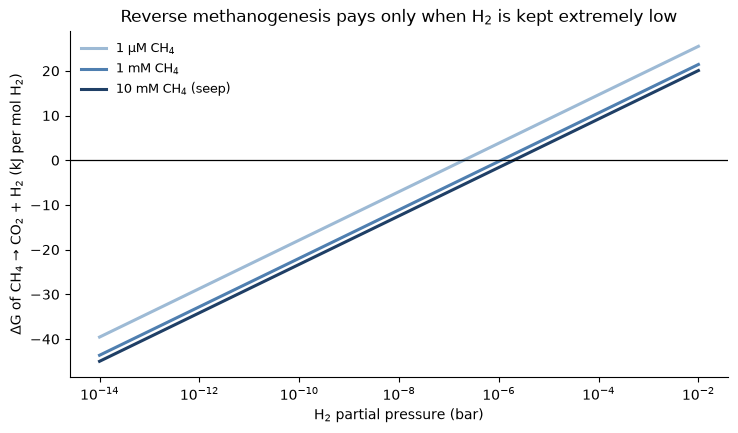

In [31]:
reverse_couples = dict(
    donor=Couple.make("methane", "CO2(aq)", key_element="C"), acceptor=("H2(g)", "H+")
)


def reverse_delta_g(ch4, h2_bar):
    """CH4 -> CO2 + H2, per H2, at the seep with this methane and hydrogen."""
    conditions = seep.replace(
        concentrations={**seep.concentrations, "Methane(aq)": ch4},
        partial_pressures={"H2(g)": h2_bar},
    )
    return mt.Reaction.from_couples(conditions=conditions, **reverse_couples).delta_G.magnitude


fig, ax = plt.subplots(figsize=(8.5, 4.5))
pressures = np.logspace(-14, -2, 200)
ch4_levels = {"1 µM CH$_4$": 1e-6, "1 mM CH$_4$": 1e-3, "10 mM CH$_4$ (seep)": 1e-2}
for (label, ch4), shade in zip(ch4_levels.items(), ("#9DBAD5", "#4F7FB0", "#1F3F66"), strict=True):
    # Straight in ln pH2, so two library points define the whole line.
    low_end, high_end = reverse_delta_g(ch4, 1e-14), reverse_delta_g(ch4, 1e-2)
    slope = (high_end - low_end) / np.log(1e-2 / 1e-14)
    ax.semilogx(
        pressures,
        low_end + slope * np.log(pressures / 1e-14),
        color=shade,
        linewidth=2.2,
        label=label,
    )
    crossing = 1e-14 * np.exp(-low_end / slope)
    print(f"{ch4:.0e} M CH4: exergonic below {crossing:.1e} bar H2")
ax.axhline(0.0, color="black", linewidth=0.9)
ax.set_xlabel("H$_2$ partial pressure (bar)")
ax.set_ylabel("ΔG of CH$_4$ → CO$_2$ + H$_2$ (kJ per mol H$_2$)")
ax.set_title("Reverse methanogenesis pays only when H$_2$ is kept extremely low")
ax.legend(frameon=False, fontsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()

More methane pushes the line down, but only a little: per H₂ the reaction
uses a quarter of a methane, so each tenfold rise in methane is worth only
a quarter of *RT* ln 10, about 1.4 kJ/mol here. Even at a seep the H₂ has
to stay below about 2 × 10⁻⁶ bar, and the sulfate reducer has to pull it that
low while still getting paid itself. That is the problem DIET and the other
mechanisms above get around.

## One thing worth taking away

The Frost diagram in section 1 contains most of this notebook. Methane and
CO₂ are the two ends of the line. **Type II** methanogens split substrates
that sit above the line. **Type I** methanogens climb the line using H₂.
**Reverse methanogenesis** climbs down it, and needs somewhere to put the
electrons. Which of these happens is decided by concentrations, especially
the H₂ concentration, and the ten orders of magnitude between two H₂
floors are enough to decide which organisms can live in a place at all.